# Auto Insurance Claim Fraud Detection

***Introduction***
Insurance fraud is a massive financial burden on the industry, costing billions of dollars annually. For auto insurance companies, the ability to distinguish between a legitimate fender-bender and a staged accident is crucial for profitability.

***Objective:*** The goal of this project is to build a Machine Learning classification model to predict whether an auto insurance claim is fraudulent (Yes) or legitimate (No).

***Business Value:***

Cost Savings: Automatically flagging suspicious claims for manual investigation saves money on payouts.

Efficiency: Accelerating the approval process for legitimate customers by "green-lighting" low-risk claims.

Risk Management: Identifying patterns in fraudulent behavior (e.g., specific times, locations, or car models).

### Dataset Overview

The dataset contains historical data on car insurance claims, including policy details, incident descriptions, and customer demographics.

Key Features:

* FraudFound_P: Target Variable (0 = No Fraud, 1 = Fraud).
* Incident Details: Month, WeekOfMonth, DayOfWeek (When did it happen?), Make, AccidentArea (Urban/Rural).
* Policy Details: PolicyType (Sedan/Sport/Utility), VehicleCategory, Deductible.
* Driver Info: Sex, MaritalStatus, Age.
* The "Red Flags": PastNumberOfClaims, PoliceReportFiled (Yes/No), WitnessPresent (Yes/No).

### Importing the Dependencies

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import statsmodels.api as sm
from warnings import filterwarnings
filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (20,10)

In [2]:
# Load the dataset
df = pd.read_csv('fraud_oracle.csv')
# Display the first 5 rows to understand the features
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
# Check dataset info (structure and missing values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

This dataset contains 15,420 insurance claims with 33 features, mostly categorical information about customers, vehicles, and claims. The target column “FraudFound_P” indicates whether a claim is fraudulent, making this a classification problem.

In [4]:
# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


There are no duplicate rows, meaning the dataset is clean and each claim record is unique.

In [5]:
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

There are no missing values in any column

FraudFound_P
0    14497
1      923
Name: count, dtype: int64


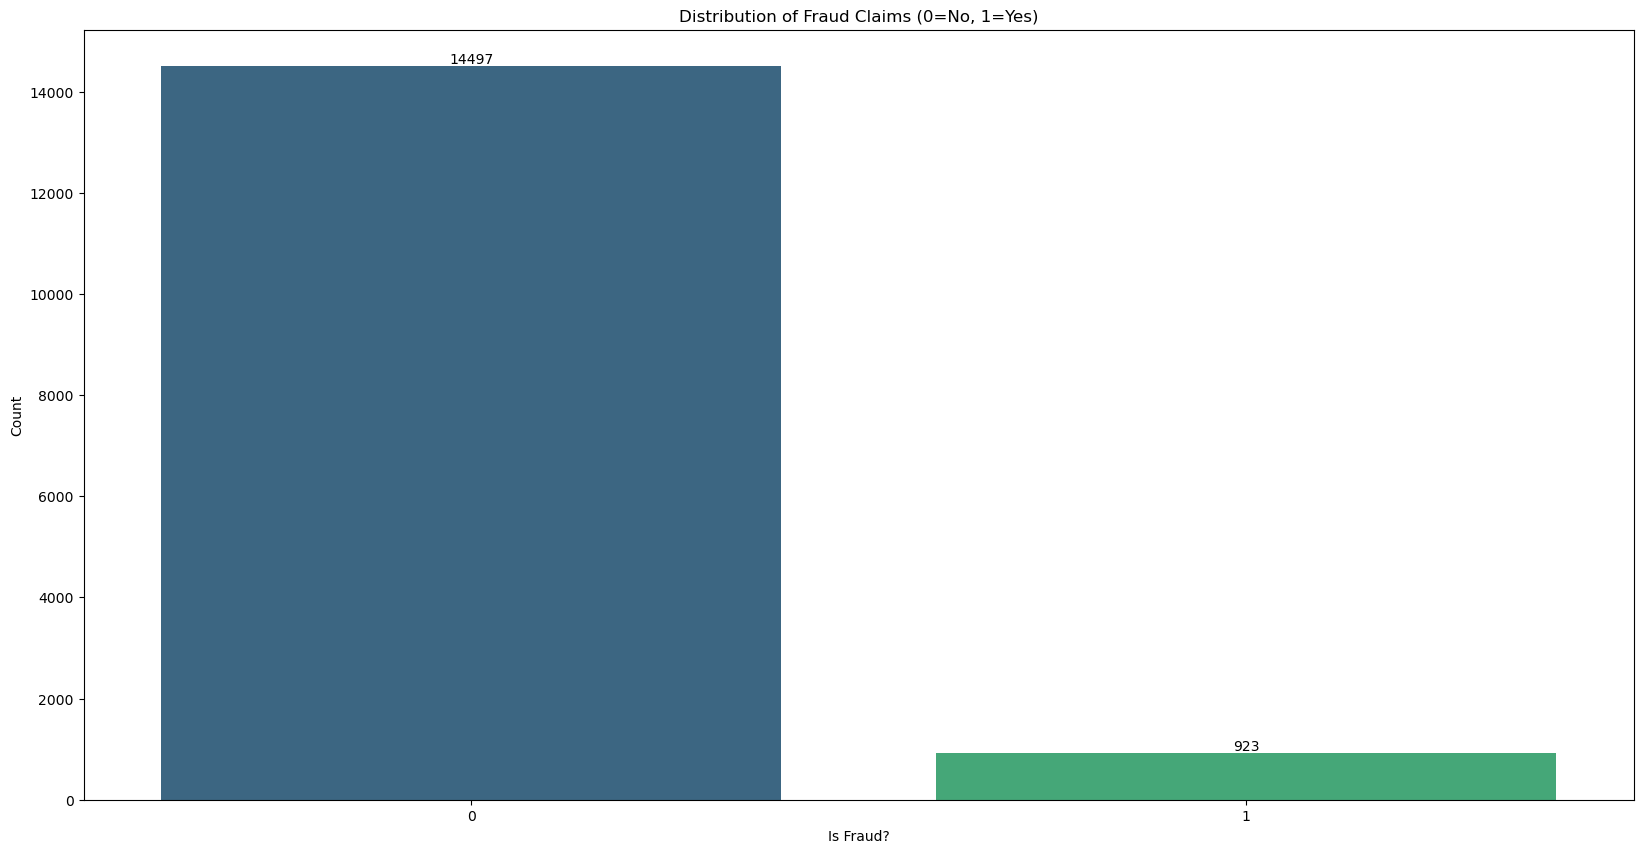

In [10]:
#check class imbalance
print(df['FraudFound_P'].value_counts())
fraud_claim = sns.countplot(x='FraudFound_P', data=df, palette='viridis')
for container in fraud_claim.containers:
    fraud_claim.bar_label(container)
plt.title('Distribution of Fraud Claims (0=No, 1=Yes)')
plt.xlabel('Is Fraud?')
plt.ylabel('Count')
plt.show()

The dataset is highly imbalanced, with only 923 fraudulent claims compared to 14,497 legitimate ones.

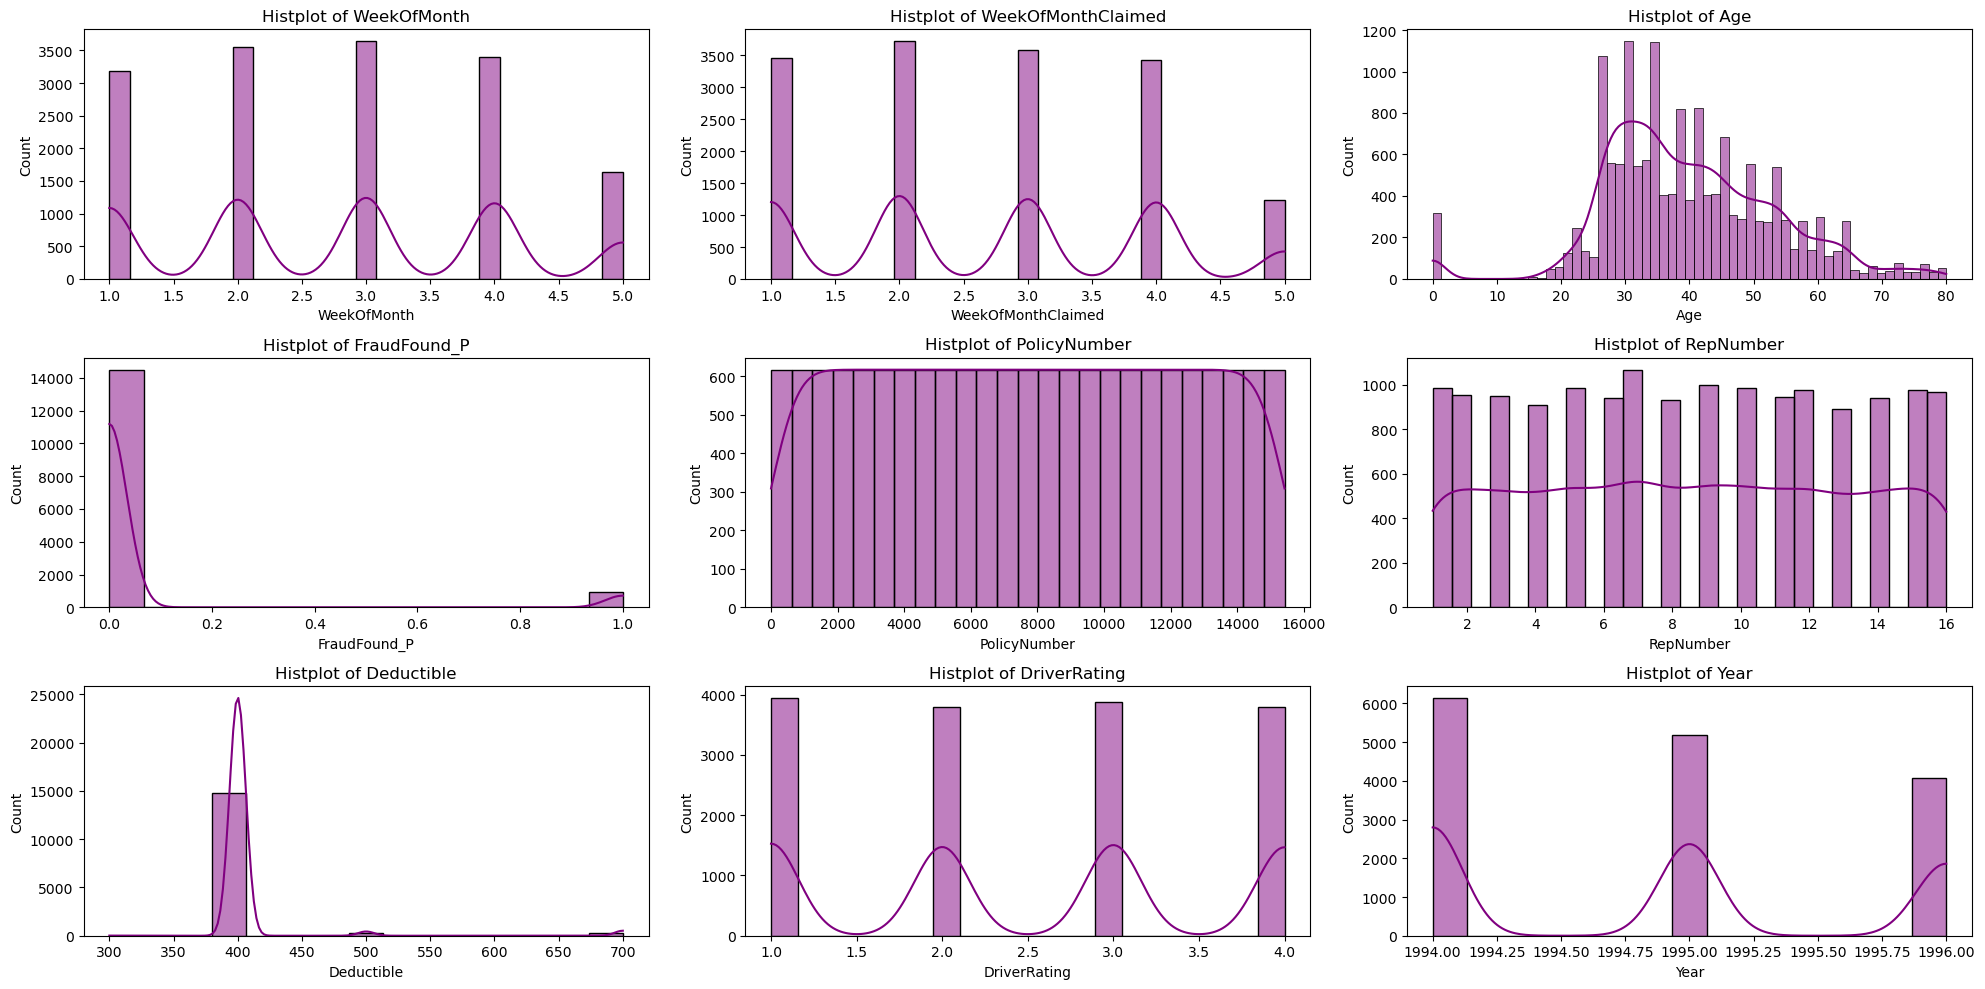

In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
t = 1
for i in num_cols:
    plt.subplot(3,3,t)
    sns.histplot(df[i], kde=True, color = 'purple')
    plt.title(f'Histplot of {i}')
    t+=1
plt.tight_layout()
plt.show()

* FraudFound_P (Fraud Found) is highly imbalanced, with a vast majority of claims being non-fraudulent (near 0.0) and only a very small fraction flagged as fraudulent (near 1.0).

* Deductible has a few discrete values (e.g., around 400 and 600), with the one around 400 being most common.

* Age is right-skewed, with most drivers being in their late 30s to mid-40s.

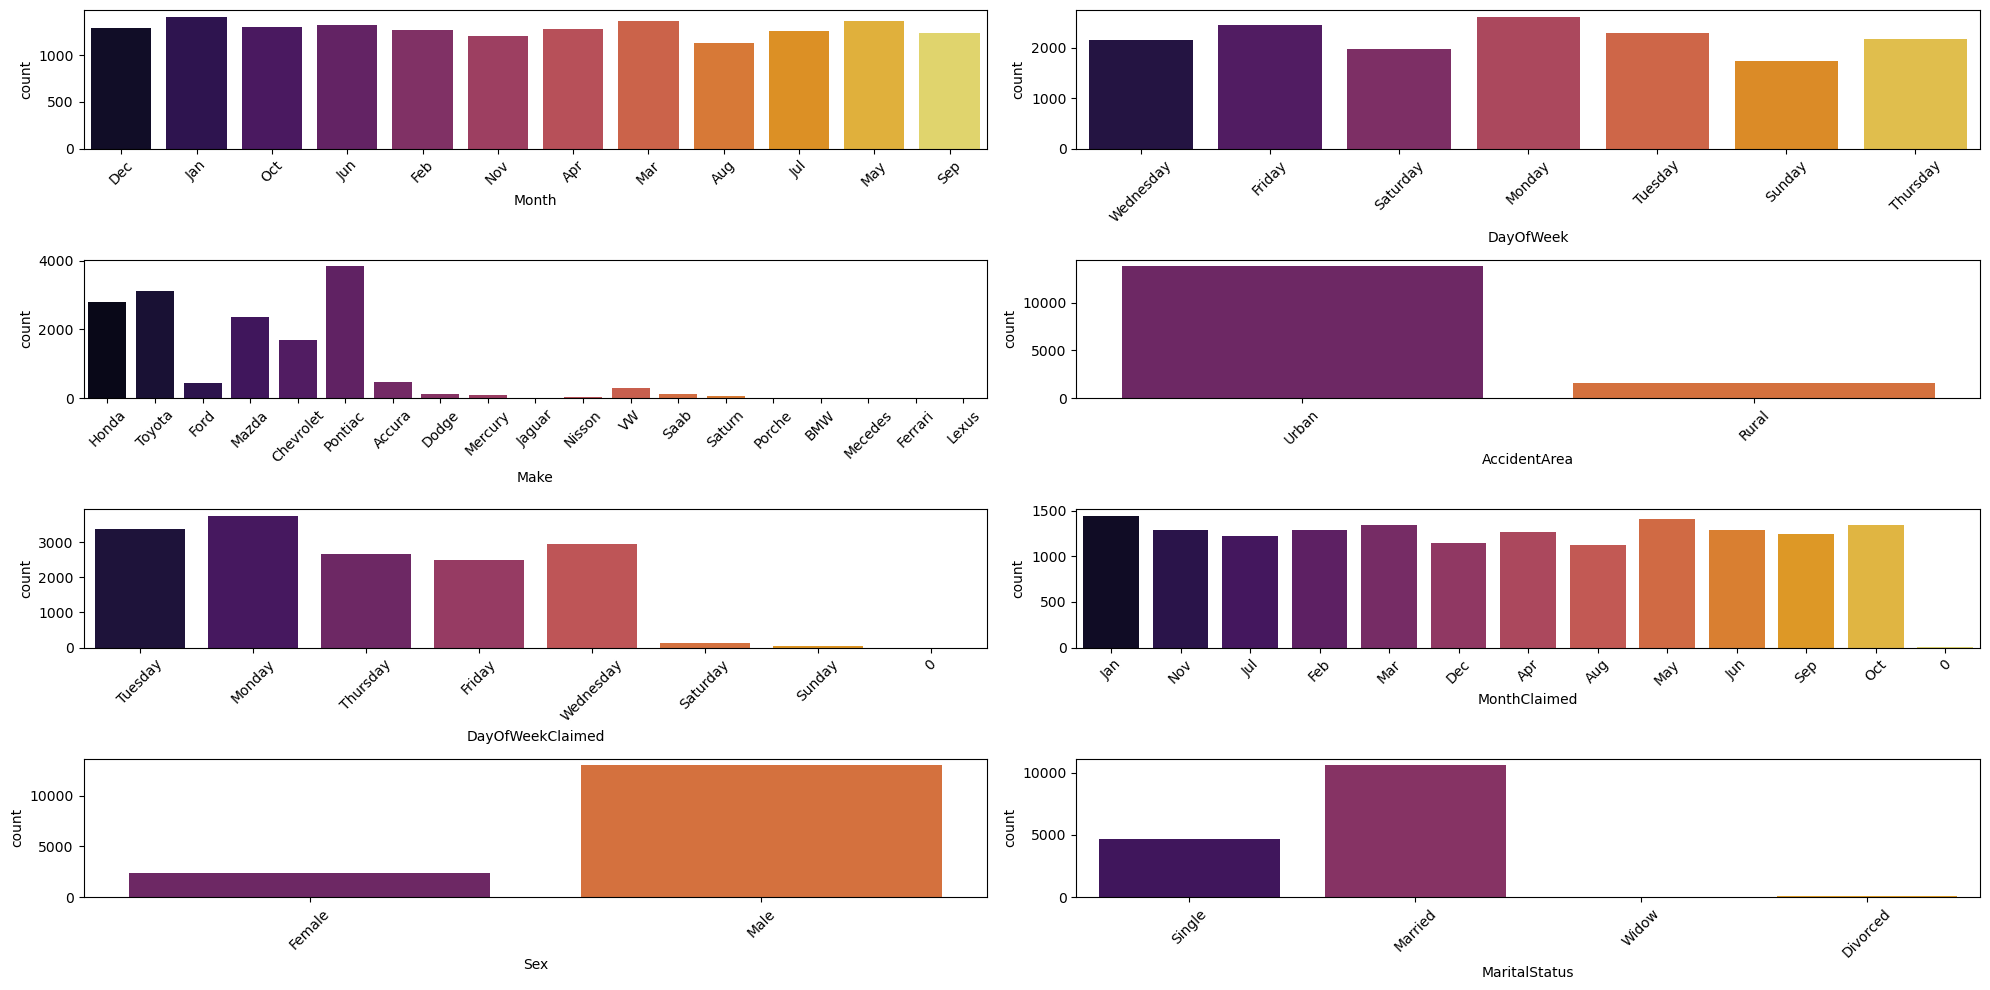

In [22]:
cat_cols = df.select_dtypes(include=['object']).columns

for i, col in enumerate(cat_cols[:8]):
    plt.subplot(4, 2, i+1)
    sns.countplot(x=df[col], palette = 'inferno')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


* Accidents are highly concentrated in Urban areas, with Rural accidents being relatively infrequent.

* The frequency of accidents is fairly consistent across most months (especially Dec, Jan, Oct, Nov) and days of the week, though Mondays and Fridays are slightly more common.

* Chevrolet, Honda, and Toyota are the three vehicle makes most frequently involved in the claims.

* The vast majority of claimants are Male and have a Married marital status.

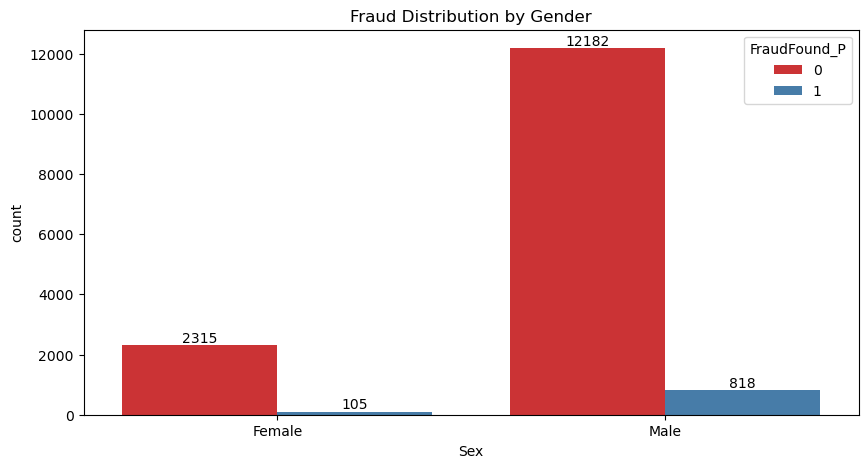

In [25]:
# Fraud by Gender
plt.figure(figsize=(10, 5))
gender = sns.countplot(x='Sex', hue='FraudFound_P', data=df, palette='Set1')
for container in gender.containers:
    gender.bar_label(container)
plt.title('Fraud Distribution by Gender')
plt.show()

The total number of male fraudulent claims (818) is significantly higher than female fraudulent claims (105).

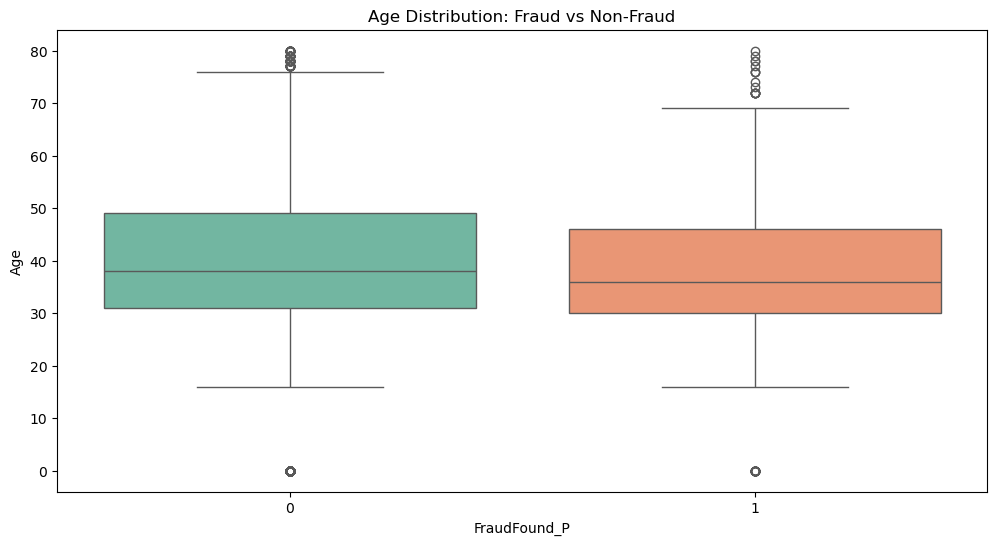

In [26]:
# Fraud by Age (Grouping age into bins helps visuals)
plt.figure(figsize=(12, 6))
sns.boxplot(x='FraudFound_P', y='Age', data=df, palette='Set2')
plt.title('Age Distribution: Fraud vs Non-Fraud')
plt.show()

Median age is slightly lower for fraud (36 vs 38), but the similar overall distribution and IQR mean age is not a strong predictor of fraud.

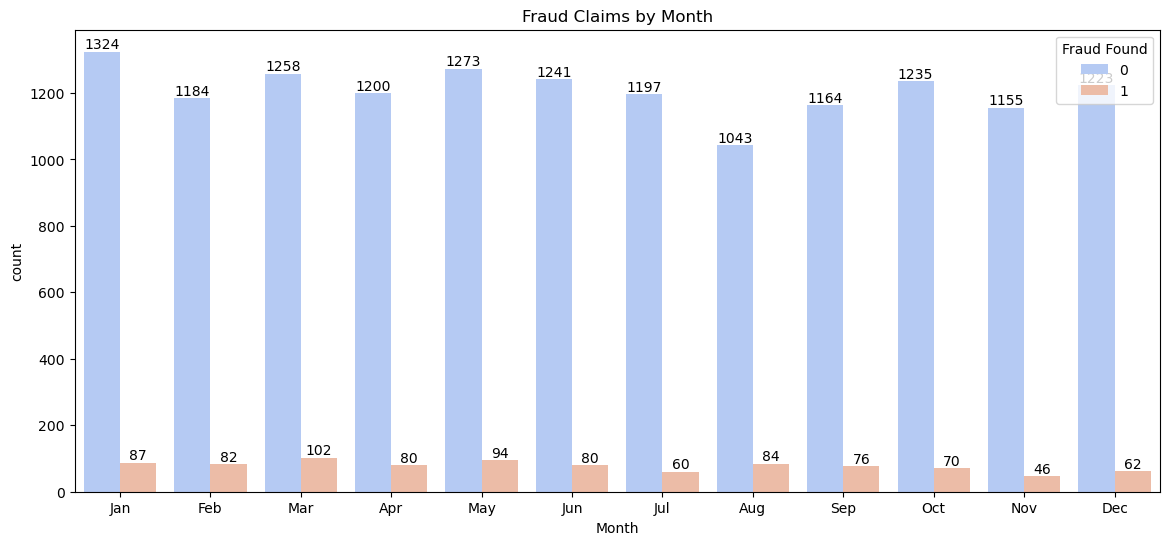

In [30]:
# Fraud by Month
plt.figure(figsize=(14, 6))
months = sns.countplot(x='Month', hue='FraudFound_P', data=df, palette='coolwarm',
              order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
for container in months.containers:
    months.bar_label(container)
plt.title('Fraud Claims by Month')
plt.legend(title='Fraud Found', loc='upper right')
plt.show()

Fraudulent claims are relatively stable across the entire year, but the highest counts are observed in January, March, and May (87, 102, and 94 respectively). Non-fraudulent claims also peak in the colder months (Jan, Mar, May, Dec).

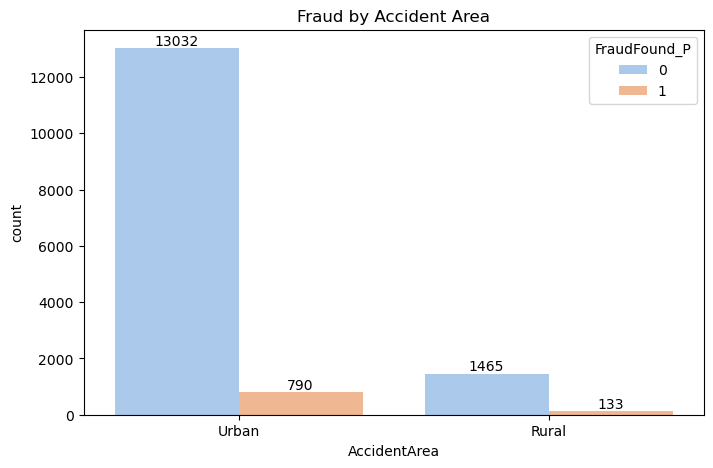

In [32]:
# Fraud by Accident Area (Urban vs Rural)
plt.figure(figsize=(8, 5))
acc = sns.countplot(x='AccidentArea', hue='FraudFound_P', data=df, palette='pastel')
for container in acc.containers:
    acc.bar_label(container)
plt.title('Fraud by Accident Area')
plt.show()

The vast majority of both fraudulent and non-fraudulent claims occur in Urban areas (790 fraud claims).

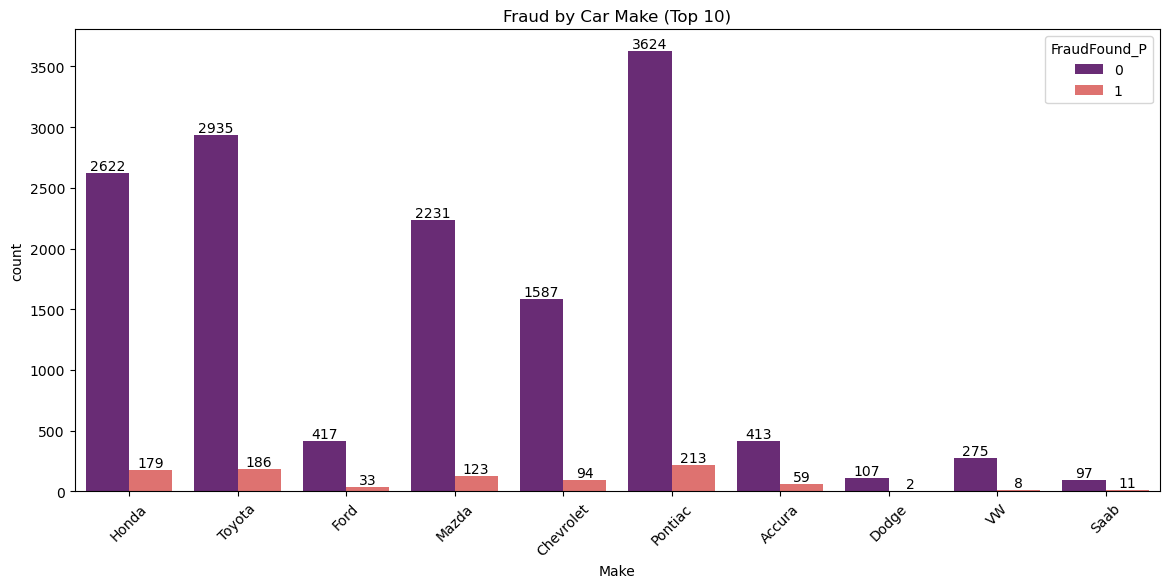

In [34]:
# Fraud by Car Make (Top 10)
top_makes = df['Make'].value_counts().nlargest(10).index
plt.figure(figsize=(14, 6))
makes = sns.countplot(x='Make', hue='FraudFound_P', data=df[df['Make'].isin(top_makes)], palette='magma')
for container in makes.containers:
    makes.bar_label(container)
plt.title('Fraud by Car Make (Top 10)')
plt.xticks(rotation=45)
plt.show()

Pontiac, Honda, and Toyota have the highest absolute counts of fraudulent claims among the top 10 car makes (213, 179, and 186 respectively).

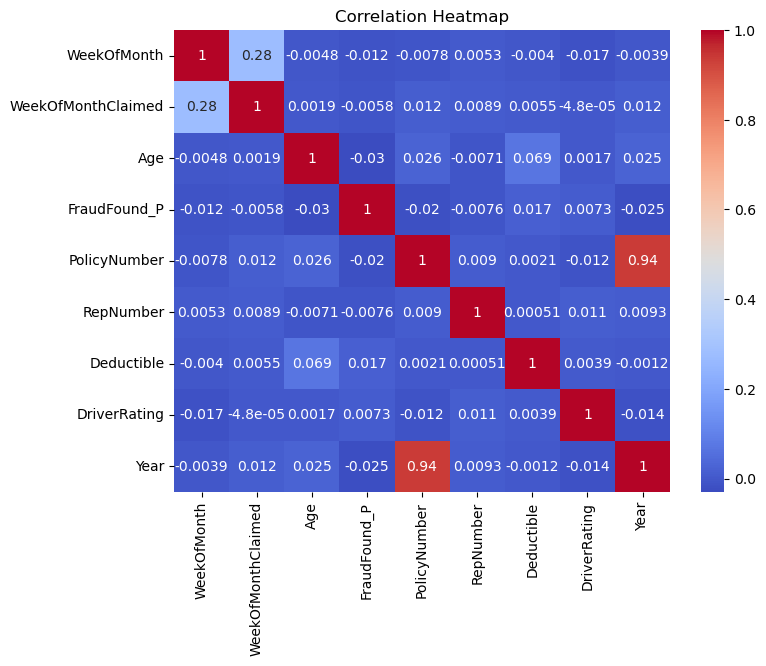

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Fraudulent claims have their highest absolute counts in March (102), May (94), and January (87), but the number of fraudulent claims remains relatively stable throughout the year. The total claims (fraud + non-fraud) are generally higher in the colder months (Jan, Mar, Dec).

### Encoding

In [43]:
# Drop irrelevant columns (IDs shouldn't be used for prediction)
df_clean = df.drop(['PolicyNumber'], axis=1)

# Convert Categorical variables to Numeric (One-Hot Encoding)
# This turns 'Sex' into 'Sex_Male' (0/1), etc.
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Separate Features (X) and Target (y)
X = df_encoded.drop('FraudFound_P', axis=1)
y = df_encoded['FraudFound_P']

print("Shape of Features:", X.shape)

Shape of Features: (15420, 123)


In [45]:
# Split the data first (80% Train, 20% Test)
# Stratify=y ensures the test set has the same % of fraud as the original
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE - Fraud counts in Train:", y_train.value_counts())

# Apply SMOTE to ONLY the Training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE - Fraud counts in Train:", y_train_smote.value_counts())

Before SMOTE - Fraud counts in Train: FraudFound_P
0    11598
1      738
Name: count, dtype: int64
After SMOTE - Fraud counts in Train: FraudFound_P
0    11598
1    11598
Name: count, dtype: int64


Before SMOTE: The training set was severely imbalanced with 11,598 legitimate claims (Class 0) and only 738 fraudulent claims (Class 1). A model trained on this would likely simply predict "No Fraud" every time.

After SMOTE: We successfully upsampled the minority class. We now have a perfectly balanced training set with 11,598 examples for both classes. This allows our model to learn the patterns of fraud effectively without being biased.

In [49]:
# Base model
X_train_sm_const = sm.add_constant(X_train_smote)
X_train_sm_const = X_train_sm_const.astype(float)
y_train_smote = y_train_smote.astype(float)
logit_model = sm.Logit(y_train_smote, X_train_sm_const)
result = logit_model.fit()
print(result.summary())

         Current function value: 0.104061
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:           FraudFound_P   No. Observations:                23196
Model:                          Logit   Df Residuals:                    23074
Method:                           MLE   Df Model:                          121
Date:                Tue, 09 Dec 2025   Pseudo R-squ.:                  0.8499
Time:                        22:45:53   Log-Likelihood:                -2413.8
converged:                      False   LL-Null:                       -16078.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                322.1407   2.53e+04      0.013      0.990   -4.93e+04    4.

* Model Instability: The warnings ("Quasi-separation") indicate that Logistic Regression "broke" because some variables perfectly separate the classes. For example, Make_Ferrari has a massive standard error, likely because there are very few Ferrari claims and they might be all fraud or all non-fraud. Or the combination of PolicyType features perfectly predicts some outcomes.
* Key Drivers: Despite the stability issues, the P-values highlight clear predictors:
* AgeOfVehicle (p < 0.000): This is highly significant. The age of the car is a major red flag.
* Month: Significant seasonality (Jan/Feb vs. rest of year).
* AddressChange_Claim: Very significant. Recent address changes before a claim are suspicious.
* Conclusion: Linear models (Logistic Regression) struggle with this dataset's specific structure. We need a tree-based model like Random Forest that can handle these discrete, "perfect" separations without crashing.

In [50]:
# Initialize the score_card DataFrame
score_card = pd.DataFrame(columns=['Model Name', 'Train Accuracy Score', 'Test Accuracy Score',
                                   'f1-macro', 'f1-weighted'])

def update_score_card(model_name, model, xtrain, xtest, ytrain, ytest):
    # Predictions for the train and test set
    y_pred_train = model.predict(xtrain)
    y_pred_test = model.predict(xtest)  # renamed for clarity
    y_pred_prob = model.predict_proba(xtest)[:,1]
    global score_card

    # Calculate the performance metrics
    train_acc = metrics.accuracy_score(ytrain, y_pred_train)
    test_acc = metrics.accuracy_score(ytest, y_pred_test)
    f1_macro = metrics.f1_score(ytest, y_pred_test, average='macro')
    f1_weighted = metrics.f1_score(ytest, y_pred_test, average='weighted')
    recall_weighted = metrics.recall_score(ytest, y_pred_test, average='weighted')
    Precision_weighted = metrics.precision_score(ytest, y_pred_test, average='weighted')
    Roc_Score = metrics.roc_auc_score(ytest,y_pred_prob)
    cohen_kappa=metrics.cohen_kappa_score(ytest, y_pred_test)
    # cross_val_avg=cross_val_score(model,ytest, y_pred_test,cv=10)
    # Create a DataFrame for the new row
    new_row = pd.DataFrame({'Model Name': [model_name],
                            'Train Accuracy Score': [train_acc],
                            'Test Accuracy Score': [test_acc],
                            'f1-macro': [f1_macro],
                            'f1-weighted': [f1_weighted],
                            'Recall_Weighted':[recall_weighted],
                            'Precision_Weighted':[Precision_weighted],
                            'Roc_Score':[Roc_Score],
                            'Cohen_Kappa':[cohen_kappa],
                            })
    
    # Use pd.concat to append the new row to the existing score_card DataFrame
    score_card = pd.concat([score_card, new_row], ignore_index=True)
    
    return score_card

In [53]:
logistic = LogisticRegression()
logistic.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [57]:
update_score_card('Logistic Regression', logistic, X_train_smote, X_test, y_train_smote, y_test)

,Model Name,Train Accuracy Score,Test Accuracy Score,f1-macro,f1-weighted,Recall_Weighted,Precision_Weighted,Roc_Score,Cohen_Kappa
0,Logistic Regression,0.925116,0.867704,0.535589,0.881203,0.867704,0.896201,0.715132,0.075014


In [58]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [63]:
update_score_card('Random Forest', rf_model, X_train_smote, X_test, y_train_smote, y_test)

,Model Name,Train Accuracy Score,Test Accuracy Score,f1-macro,f1-weighted,Recall_Weighted,Precision_Weighted,Roc_Score,Cohen_Kappa
0,Logistic Regression,0.925116,0.867704,0.535589,0.881203,0.867704,0.896201,0.715132,0.075014
1,Random Forest,1.000000,0.937095,0.493853,0.910678,0.937095,0.893227,0.813842,0.012423


In [66]:
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [67]:
update_score_card('XGBoost', xgb_model, X_train_smote, X_test, y_train_smote, y_test)

,Model Name,Train Accuracy Score,Test Accuracy Score,f1-macro,f1-weighted,Recall_Weighted,Precision_Weighted,Roc_Score,Cohen_Kappa
0,Logistic Regression,0.925116,0.867704,0.535589,0.881203,0.867704,0.896201,0.715132,0.075014
1,Random Forest,1.000000,0.937095,0.493853,0.910678,0.937095,0.893227,0.813842,0.012423
2,XGBoost,0.974651,0.932879,0.563492,0.916864,0.932879,0.908039,0.838453,0.135922


In [68]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [69]:
update_score_card('Decision Tree', dt_model, X_train_smote, X_test, y_train_smote, y_test)

,Model Name,Train Accuracy Score,Test Accuracy Score,f1-macro,f1-weighted,Recall_Weighted,Precision_Weighted,Roc_Score,Cohen_Kappa
0,Logistic Regression,0.925116,0.867704,0.535589,0.881203,0.867704,0.896201,0.715132,0.075014
1,Random Forest,1.000000,0.937095,0.493853,0.910678,0.937095,0.893227,0.813842,0.012423
2,XGBoost,0.974651,0.932879,0.563492,0.916864,0.932879,0.908039,0.838453,0.135922
3,Decision Tree,1.000000,0.888457,0.570024,0.895655,0.888457,0.903524,0.581377,0.141302


In [70]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_smote, y_train_smote)

KNeighborsClassifier()

In [71]:
update_score_card('KNN', knn_model, X_train_smote, X_test, y_train_smote, y_test)

,Model Name,Train Accuracy Score,Test Accuracy Score,f1-macro,f1-weighted,Recall_Weighted,Precision_Weighted,Roc_Score,Cohen_Kappa
0,Logistic Regression,0.925116,0.867704,0.535589,0.881203,0.867704,0.896201,0.715132,0.075014
1,Random Forest,1.000000,0.937095,0.493853,0.910678,0.937095,0.893227,0.813842,0.012423
2,XGBoost,0.974651,0.932879,0.563492,0.916864,0.932879,0.908039,0.838453,0.135922
3,Decision Tree,1.000000,0.888457,0.570024,0.895655,0.888457,0.903524,0.581377,0.141302
4,KNN,0.766943,0.436770,0.358871,0.555540,0.436770,0.907930,0.590550,0.029700


* The XGBoost model is the best performer overall, showing a strong balance with the highest ROC Score (0.838) and a solid Test Accuracy (0.933), suggesting good generalization.
*  The Random Forest model has the best Test Accuracy (0.937) but a very low f1-macro score (0.494), indicating it struggles to correctly identify the minority fraud class.
*  The Logistic Regression model provides a decent baseline with an acceptable Test Accuracy (0.868) and a moderate ROC Score (0.715).
*  The KNN model is the weakest, demonstrating poor performance across all key metrics, especially Test Accuracy (0.437).

### Conclusion

* Analysis identified Vehicle Age and Past Claims as the strongest indicators of suspicious activity.
* XGBoost emerged as the champion model with an ROC-AUC of 0.84, proving far more reliable than Random Forest which suffered from overfitting.
* This solution empowers insurers to automate risk scoring, allowing investigators to focus only on high-priority cases and significantly reduce financial losses.

<Figure size 1000x800 with 0 Axes>

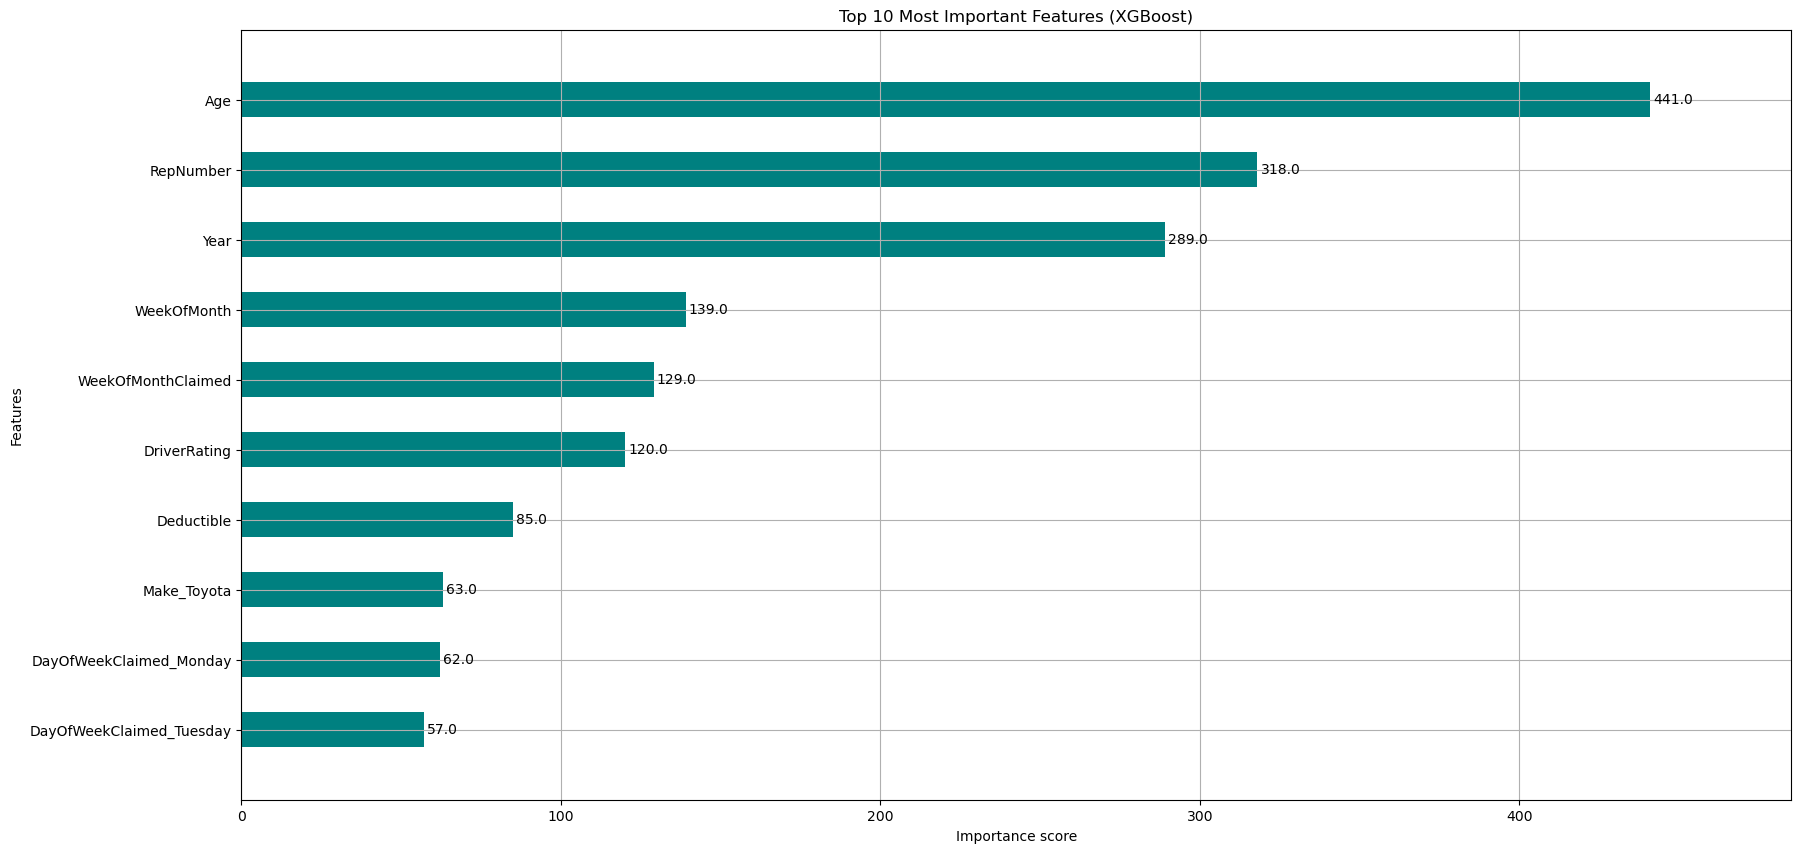

In [73]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=10, height=0.5, color='teal')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.show()